<a href="https://colab.research.google.com/github/nishachaudhary6396/Data_Engineering_Azure/blob/machinelearning/IntroductionToMl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Example without using any model

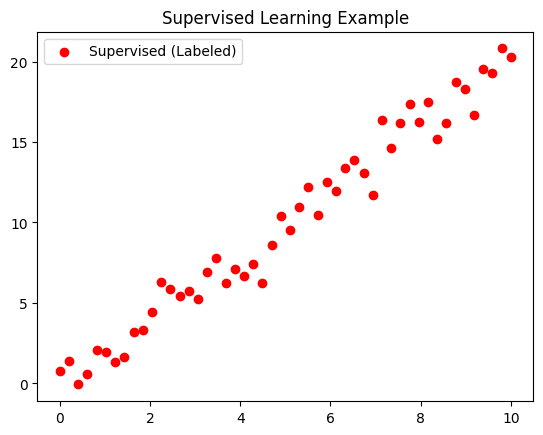

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 50)
y = 2*x + np.random.randn(50)

plt.scatter(x, y, color='red', label='Supervised (Labeled)')
plt.title("Supervised Learning Example")
plt.legend()
plt.show()

### California dataset

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Load dataset
california = fetch_california_housing(as_frame=True)
df = california.frame

# Display
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [ ]:
#Feature and target separtion
x = df.drop('MedHouseVal',axis=1)
y = df['MedHouseVal']

### Spliting Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Samples:", x_train.shape[0])
print("Testing Samples:", y_test.shape[0])


Training Samples: 16512
Testing Samples: 4128


### Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

#### Cross Validation

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

model = LinearRegression()
scores = cross_val_score(model,x_train_scaled,y_train,cv=5,scoring='r2')
print("cross-validation scores:", scores)
print("Average:", scores.mean() )

cross-validation scores: [0.62011512 0.61298876 0.6134416  0.61069973 0.60017477]
Average: 0.6114839952560993


### Practice Problem
first create some missing values and then fill them with the mean of the column then check if their any missing values left

In [ ]:
import numpy as np

# create null values in 2 columns
df_null = df.copy()
df_null.loc[df_null.sample(frac=0.6).index, 'MedInc'] = np.nan
df_null.loc[df_null.sample(frac=0.6).index, 'AveRooms'] = np.nan

# fill missing values using mean
df_null.fillna(df_null.mean(),inplace=True)

#check if null value present
df_null.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0
